# Telecom Customer Churn - Previsao com MLP

Pipeline completo de Machine Learning usando uma Rede Neural Artificial (Multi-Layer Perceptron) para prever churn de clientes de telecomunicacoes.

**Estrutura:**
- ETAPA 1 — Carregamento e diagnostico inicial
- ETAPA 2 — Limpeza dos dados
- ETAPA 3 — Preparacao e split estratificado
- ETAPA 4 — Treinamento da MLP com Pipeline
- ETAPA 5 — Avaliacao do modelo
- ETAPA 6 — Simulacao de novos clientes

## ETAPA 1 — Carregamento

### Imports e configuracao

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.30

# Colunas numericas continuas que exigem escalonamento para a MLP
NUMERIC_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges']

DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn_original.csv")

### Carga e diagnostico inicial

In [5]:
df_raw = pd.read_csv(DATA_PATH)

print('Arquivo:', DATA_PATH)
print('Linhas:', df_raw.shape[0], 'Colunas:', df_raw.shape[1])
print('Valores nulos detectados pelo pandas:', df_raw.isna().sum().sum())
print('Espacos em branco em TotalCharges:', df_raw['TotalCharges'].astype(str).str.strip().eq('').sum())

df_raw.head()

Arquivo: WA_Fn-UseC_-Telco-Customer-Churn.csv
Linhas: 7043 Colunas: 21
Valores nulos detectados pelo pandas: 0
Espacos em branco em TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df_raw['Churn'].value_counts(normalize=True).rename('proportion')

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## ETAPA 2 — Limpeza

Etapas reaproveitadas: tratamento dos espacos em branco de `TotalCharges` (convertidos para `0` e depois para `float64`), remocao de `customerID` (identificador sem poder preditivo) e remocao de categorias redundantes geradas por servicos indisponiveis. O dataset original nao tinha etapa explicita de tratamento de outliers, entao nenhuma foi adicionada.

In [7]:
df_clean = df_raw.copy()

# Reaproveita a regra original: os 11 espacos em branco de TotalCharges viram zero.
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace({' ': '0'}).astype('float64')

# Identificador sem poder preditivo e sem utilidade para a MLP.
df_clean = df_clean.drop(columns=['customerID'])

# Mantem uma copia limpa ainda categorica para auditoria/EDA futura.
df_clean_categorical = df_clean.copy()

print('Linhas:', df_clean.shape[0], 'Colunas:', df_clean.shape[1])
print('Valores nulos apos limpeza:', df_clean.isna().sum().sum())
df_clean.head()

Linhas: 7043 Colunas: 20
Valores nulos apos limpeza: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## ETAPA 3 — Preparacao

### Transformacao de variaveis categoricas

Variaveis binarias sao convertidas para 0/1 com mapeamento explicito armazenado em `category_mappings` — esse dicionario sera reutilizado na simulacao de novos clientes para garantir consistencia. Variaveis com mais de duas categorias recebem one-hot encoding. Colunas redundantes sao removidas.

In [8]:
df_mlp = df_clean.copy()

# Mapeamento explicito do alvo para evitar dependencia da ordem dos dados.
df_mlp['Churn'] = df_mlp['Churn'].map({'No': 0, 'Yes': 1})

categorical_cols = [
    col for col in df_mlp.columns
    if col != 'Churn' and (df_mlp[col].dtype == 'object' or col == 'SeniorCitizen')
]

category_mappings = {'Churn': {'No': 0, 'Yes': 1}}
for col in categorical_cols:
    if df_mlp[col].nunique() == 2:
        unique_values = sorted(df_mlp[col].dropna().unique().tolist(), key=str)
        mapping = {category: code for code, category in enumerate(unique_values)}
        df_mlp[col] = df_mlp[col].map(mapping)
        category_mappings[col] = {str(category): int(code) for category, code in mapping.items()}
    else:
        df_mlp = pd.get_dummies(df_mlp, columns=[col], dtype=int)

redundant_columns = df_mlp.columns[df_mlp.columns.str.contains('No internet service')].tolist()
redundant_columns += [
    'MultipleLines_No phone service',
    'MultipleLines_No',
    'OnlineSecurity_No',
    'OnlineBackup_No',
    'DeviceProtection_No',
    'TechSupport_No',
    'StreamingTV_No',
    'StreamingMovies_No',
]
redundant_columns = [col for col in redundant_columns if col in df_mlp.columns]

df_mlp = df_mlp.drop(columns=redundant_columns)

print('Mapeamentos binarios:', category_mappings)
print('Colunas removidas por redundancia:', redundant_columns)
print('Shape final antes do split:', df_mlp.shape)
df_mlp.head()

Mapeamentos binarios: {'Churn': {'No': 0, 'Yes': 1}, 'gender': {'Female': 0, 'Male': 1}, 'SeniorCitizen': {'0': 0, '1': 1}, 'Partner': {'No': 0, 'Yes': 1}, 'Dependents': {'No': 0, 'Yes': 1}, 'PhoneService': {'No': 0, 'Yes': 1}, 'PaperlessBilling': {'No': 0, 'Yes': 1}}
Colunas removidas por redundancia: ['OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'MultipleLines_No phone service', 'MultipleLines_No', 'OnlineSecurity_No', 'OnlineBackup_No', 'DeviceProtection_No', 'TechSupport_No', 'StreamingTV_No', 'StreamingMovies_No']
Shape final antes do split: (7043, 27)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,1,0,0,0,0,1,0


### Separacao entre features e alvo

In [9]:
X_mlp = df_mlp.drop(columns=['Churn'])
y_mlp = df_mlp['Churn']

print('Features:', X_mlp.shape)
print('Target:', y_mlp.shape)
print('Distribuicao do target:')
print(y_mlp.value_counts(normalize=True).sort_index())

Features: (7043, 26)
Target: (7043,)
Distribuicao do target:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


### Split estratificado

O split estratificado preserva a proporcao de churn nos conjuntos de treino e teste. O escalonamento sera aplicado dentro do Pipeline na ETAPA 4, garantindo que o `StandardScaler` seja ajustado apenas com dados de treino e evitando vazamento de informacao (data leakage).

In [10]:
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_mlp,
    y_mlp,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_mlp,
)

print('Treino:', X_train_mlp.shape, y_train_mlp.shape)
print('Teste: ', X_test_mlp.shape, y_test_mlp.shape)
print('\nDistribuicao do target — treino:')
print(y_train_mlp.value_counts(normalize=True).sort_index())
print('\nDistribuicao do target — teste:')
print(y_test_mlp.value_counts(normalize=True).sort_index())

Treino: (4930, 26) (4930,)
Teste:  (2113, 26) (2113,)

Distribuicao do target — treino:
Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Distribuicao do target — teste:
Churn
0    0.734501
1    0.265499
Name: proportion, dtype: float64


### Objetos prontos para o treinamento

`X_train_mlp` e `X_test_mlp` sao os conjuntos brutos (sem escalonamento). O Pipeline definido na ETAPA 4 aplica `StandardScaler` nas colunas numericas internamente antes de passar para a MLP, garantindo reproducibilidade e ausencia de leakage.

In [11]:
mlp_preparation_artifacts = {
    'X_train': X_train_mlp,
    'X_test': X_test_mlp,
    'y_train': y_train_mlp,
    'y_test': y_test_mlp,
    'feature_names': X_train_mlp.columns.tolist(),
    'category_mappings': category_mappings,
    'removed_redundant_columns': redundant_columns,
}

mlp_preparation_artifacts.keys()

dict_keys(['X_train', 'X_test', 'y_train', 'y_test', 'feature_names', 'category_mappings', 'removed_redundant_columns'])

## ETAPA 4 — Treinamento da MLP

O modelo e encapsulado em um `Pipeline` do sklearn com dois estagios:

1. **`preprocessor`** (`ColumnTransformer`): aplica `StandardScaler` apenas nas colunas numericas continuas (`tenure`, `MonthlyCharges`, `TotalCharges`). As demais colunas (ja binarias/dummy) passam sem transformacao (`remainder='passthrough'`).
   - *Por que normalizar para redes neurais?* MLPs usam gradiente descendente e funcoes de ativacao sensiveis a magnitude. Features em escalas muito diferentes (ex: `tenure` 0–72 vs `TotalCharges` 0–8000) fazem o gradiente convergir lento ou de forma enviesada. `StandardScaler` centraliza cada feature em media 0 e desvio padrao 1, deixando o treino estavel.

2. **`classifier`** (`MLPClassifier`): rede com camadas ocultas configuradas em `MLP_HIDDEN_LAYER_SIZES`.
   - *Funcao das camadas ocultas:* cada camada aprende representacoes abstratas dos dados. A primeira camada detecta padroes simples (ex: cliente com tenure baixo); camadas seguintes combinam esses padroes para decisoes mais complexas (ex: tenure baixo + contrato mensal + fiber optic = alto risco de churn).

Para testar outra arquitetura, altere apenas `MLP_HIDDEN_LAYER_SIZES`, por exemplo `(64,)`, `(64, 32)` ou `(128, 64, 32)`.

In [12]:
MLP_HIDDEN_LAYER_SIZES = (64, 32)
MLP_MAX_ITER = 500
MLP_LEARNING_RATE_INIT = 0.001

# ColumnTransformer: escala numericas, repassa binarias/dummies sem alteracao
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), NUMERIC_FEATURES),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

# Pipeline: preprocessamento + MLP em um unico objeto reproduzivel
pipeline_mlp = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=MLP_HIDDEN_LAYER_SIZES,
        activation='relu',
        solver='adam',
        learning_rate_init=MLP_LEARNING_RATE_INIT,
        max_iter=MLP_MAX_ITER,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
    )),
])

pipeline_mlp.fit(X_train_mlp, y_train_mlp)

mlp_classifier = pipeline_mlp.named_steps['classifier']
print('Arquitetura (camadas ocultas):', mlp_classifier.hidden_layer_sizes)
print('Iteracoes realizadas:         ', mlp_classifier.n_iter_)
print('Loss final (log-loss treino): ', f'{mlp_classifier.loss_:.6f}')

Arquitetura (camadas ocultas): (64, 32)
Iteracoes realizadas:          34
Loss final (log-loss treino):  0.382455


### Artefatos do modelo

`mlp_model_artifacts` agrupa o pipeline completo e os parametros usados. Para fazer previsoes em novos dados, use `pipeline_mlp.predict(X)` ou `pipeline_mlp.predict_proba(X)` — o escalonamento e aplicado automaticamente.

In [13]:
mlp_model_artifacts = {
    **mlp_preparation_artifacts,
    'pipeline': pipeline_mlp,
    'hidden_layer_sizes': MLP_HIDDEN_LAYER_SIZES,
    'max_iter': MLP_MAX_ITER,
    'learning_rate_init': MLP_LEARNING_RATE_INIT,
    'random_state': RANDOM_STATE,
}

mlp_model_artifacts.keys()

dict_keys(['X_train', 'X_test', 'y_train', 'y_test', 'feature_names', 'category_mappings', 'removed_redundant_columns', 'pipeline', 'hidden_layer_sizes', 'max_iter', 'learning_rate_init', 'random_state'])

## ETAPA 5 — Avaliacao

### Metricas de classificacao

Interpretacao das metricas para o problema de churn:

- **Accuracy**: percentual de predicoes corretas no total — pouco informativo em datasets desbalanceados (26% churn vs 74% nao-churn).
- **Precision**: dos clientes previstos como churn, quantos realmente deram churn. Alta precision = menos falsos alarmes.
- **Recall**: dos clientes que realmente deram churn, quantos o modelo identificou. Alto recall = menos churns perdidos. *Para negocios, recall costuma ser mais critico: e pior perder um cliente que acionar erroneamente uma retencao.*
- **F1-Score**: media harmonica entre precision e recall — util quando ha desbalanceamento de classes.
- **ROC-AUC**: area sob a curva ROC. Mede a capacidade do modelo de separar as classes em diferentes thresholds. Valor 1.0 = perfeito; 0.5 = aleatorio.
- **PR-AUC**: area sob a curva Precision-Recall. Mais informativa que ROC-AUC quando as classes sao desbalanceadas.

In [14]:
y_pred = pipeline_mlp.predict(X_test_mlp)
y_proba = pipeline_mlp.predict_proba(X_test_mlp)[:, 1]

acc = accuracy_score(y_test_mlp, y_pred)
prec = precision_score(y_test_mlp, y_pred)
rec = recall_score(y_test_mlp, y_pred)
f1 = f1_score(y_test_mlp, y_pred)
roc_auc = roc_auc_score(y_test_mlp, y_proba)
pr_auc = average_precision_score(y_test_mlp, y_proba)

print('=' * 40)
print('       METRICAS DA MLP — CONJUNTO TESTE')
print('=' * 40)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print(f'  PR-AUC    : {pr_auc:.4f}')
print('=' * 40)
print()
print('Classification Report:')
print(classification_report(y_test_mlp, y_pred, target_names=['Nao Churn (0)', 'Churn (1)']))

       METRICAS DA MLP — CONJUNTO TESTE
  Accuracy  : 0.8022
  Precision : 0.6629
  Recall    : 0.5187
  F1-Score  : 0.5820
  ROC-AUC   : 0.8442
  PR-AUC    : 0.6440

Classification Report:
               precision    recall  f1-score   support

Nao Churn (0)       0.84      0.90      0.87      1552
    Churn (1)       0.66      0.52      0.58       561

     accuracy                           0.80      2113
    macro avg       0.75      0.71      0.73      2113
 weighted avg       0.79      0.80      0.79      2113



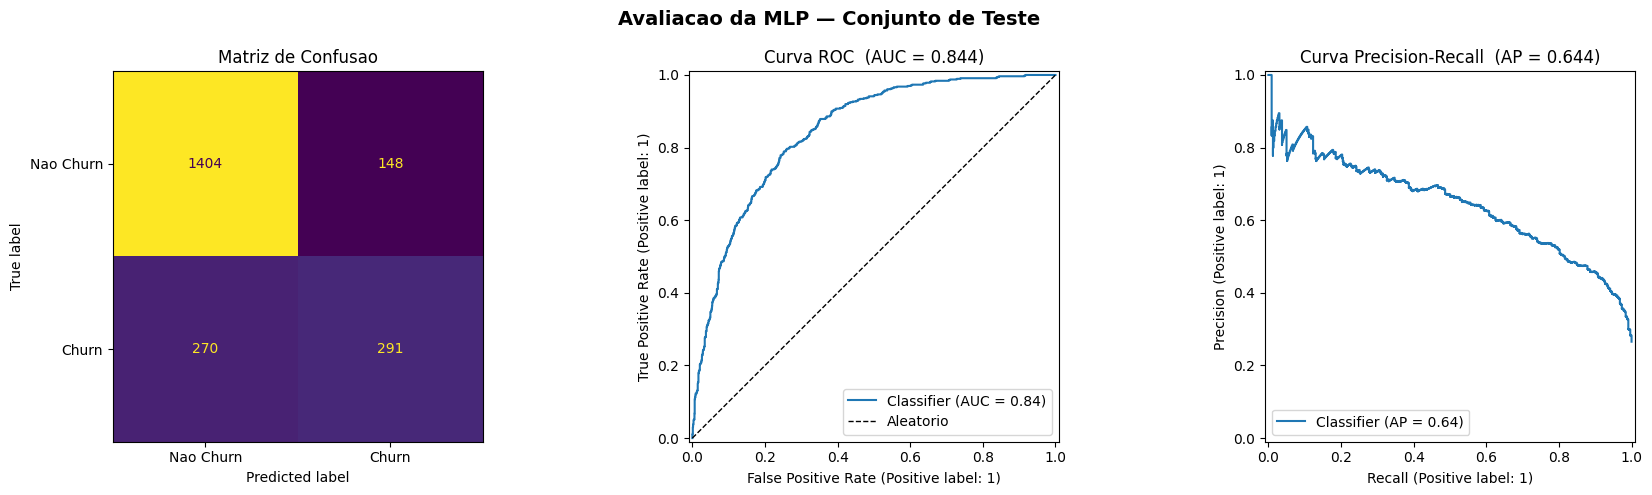

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Avaliacao da MLP — Conjunto de Teste', fontsize=14, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test_mlp, y_pred,
    display_labels=['Nao Churn', 'Churn'],
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('Matriz de Confusao')

RocCurveDisplay.from_predictions(y_test_mlp, y_proba, ax=axes[1])
axes[1].set_title(f'Curva ROC  (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
axes[1].legend()

PrecisionRecallDisplay.from_predictions(y_test_mlp, y_proba, ax=axes[2])
axes[2].set_title(f'Curva Precision-Recall  (AP = {pr_auc:.3f})')

plt.tight_layout()
plt.show()

## ETAPA 6 — Simulacao de Novos Clientes

Os 5 clientes fictícios sao criados no formato bruto do CSV original (mesmas colunas de `df_clean_categorical`). Em seguida aplicamos as **exatamente as mesmas transformacoes** do treinamento:

1. Mapeamento binario via `category_mappings` (armazenado na ETAPA 3).
2. `get_dummies` para colunas multi-categoria restantes.
3. Remocao das colunas redundantes (`redundant_columns`).
4. `reindex` com `feature_names` para alinhar colunas — colunas ausentes viram `0`, colunas desconhecidas sao descartadas.
5. Previsao via `pipeline_mlp.predict` / `predict_proba` (o escalonamento e aplicado automaticamente pelo Pipeline).

Como a previsao de churn e realizada: o Pipeline transforma os dados brutos com o mesmo `StandardScaler` ajustado no treino e passa para a MLP, que retorna a probabilidade de cada classe. O threshold padrao e 0.5 — probabilidade > 50% = Churn.

In [16]:
def preprocessar_novos_clientes(df_novos, category_mappings, redundant_columns, feature_names):
    """Replica as transformacoes da ETAPA 3 em novos dados para garantir consistencia."""
    df = df_novos.copy()

    binary_cols = [col for col in category_mappings if col != 'Churn']
    for col in binary_cols:
        if col in df.columns:
            mapping = category_mappings[col]
            # Suporta valores originais como string ou inteiro
            df[col] = df[col].apply(lambda x: mapping.get(str(x), mapping.get(x, x)))

    multi_cat_cols = [col for col in df.columns if df[col].dtype == 'object']
    if multi_cat_cols:
        df = pd.get_dummies(df, columns=multi_cat_cols, dtype=int)

    df = df.drop(columns=[c for c in redundant_columns if c in df.columns])

    # Alinha colunas com o treino: adiciona dummies ausentes como 0, descarta desconhecidos
    df = df.reindex(columns=feature_names, fill_value=0)
    return df


novos_clientes_raw = pd.DataFrame([
    {
        # Cliente 1: contrato longo, seguro, sem churn esperado
        'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
        'tenure': 48, 'PhoneService': 'Yes', 'MultipleLines': 'No',
        'InternetService': 'Fiber optic', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'No',
        'StreamingMovies': 'No', 'Contract': 'Two year', 'PaperlessBilling': 'No',
        'PaymentMethod': 'Bank transfer (automatic)',
        'MonthlyCharges': 79.85, 'TotalCharges': 3832.80,
    },
    {
        # Cliente 2: recente, sem suporte, mensal com fibra — alto risco
        'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
        'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'Yes',
        'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
        'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 95.70, 'TotalCharges': 191.40,
    },
    {
        # Cliente 3: senior, mensal, DSL, conta media — risco moderado
        'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'No', 'Dependents': 'No',
        'tenure': 12, 'PhoneService': 'Yes', 'MultipleLines': 'No',
        'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes',
        'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No',
        'StreamingMovies': 'No', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Mailed check',
        'MonthlyCharges': 45.20, 'TotalCharges': 542.40,
    },
    {
        # Cliente 4: familia, contrato longo, servicos completos — baixo risco
        'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
        'tenure': 60, 'PhoneService': 'Yes', 'MultipleLines': 'Yes',
        'InternetService': 'DSL', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes', 'Contract': 'Two year', 'PaperlessBilling': 'No',
        'PaymentMethod': 'Credit card (automatic)',
        'MonthlyCharges': 84.65, 'TotalCharges': 5079.00,
    },
    {
        # Cliente 5: senior, recente, fibra cara, mensal — alto risco
        'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'No', 'Dependents': 'No',
        'tenure': 5, 'PhoneService': 'Yes', 'MultipleLines': 'No',
        'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
        'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes',
        'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
        'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 88.50, 'TotalCharges': 442.50,
    },
])

feature_names = mlp_preparation_artifacts['feature_names']
novos_clientes_proc = preprocessar_novos_clientes(
    novos_clientes_raw, category_mappings, redundant_columns, feature_names
)

print('Shape apos preprocessamento:', novos_clientes_proc.shape)
novos_clientes_proc

Shape apos preprocessamento: (5, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_Yes,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,48,1,0,79.85,3832.8,0,...,1,0,0,0,0,1,1,0,0,0
1,1,0,0,0,2,1,1,95.70,191.4,1,...,0,1,1,1,0,0,0,0,1,0
2,0,1,0,0,12,1,1,45.20,542.4,0,...,0,0,0,1,0,0,0,0,0,1
3,1,0,1,1,60,1,0,84.65,5079.0,1,...,1,1,1,0,0,1,0,1,0,0
4,0,1,0,0,5,1,1,88.50,442.5,0,...,0,1,1,1,0,0,0,0,1,0


In [17]:
predicoes = pipeline_mlp.predict(novos_clientes_proc)
probabilidades = pipeline_mlp.predict_proba(novos_clientes_proc)[:, 1]

resultados = pd.DataFrame({
    'Cliente': [f'Cliente {i + 1}' for i in range(len(novos_clientes_raw))],
    'Tenure (meses)': novos_clientes_raw['tenure'].values,
    'Contrato': novos_clientes_raw['Contract'].values,
    'Internet': novos_clientes_raw['InternetService'].values,
    'Mensalidade (R$)': novos_clientes_raw['MonthlyCharges'].values,
    'Predicao': ['Churn' if p == 1 else 'Nao Churn' for p in predicoes],
    'Prob. Churn (%)': (probabilidades * 100).round(2),
})

print('=' * 55)
print('       SIMULACAO — PREVISAO DE CHURN POR CLIENTE')
print('=' * 55)
for _, row in resultados.iterrows():
    status = '>>> RISCO' if row['Predicao'] == 'Churn' else '    ok   '
    print(f"  {row['Cliente']} | {status} | {row['Predicao']:<10} | {row['Prob. Churn (%)']:>6.2f}%")
print('=' * 55)
print()

resultados

       SIMULACAO — PREVISAO DE CHURN POR CLIENTE
  Cliente 1 |     ok    | Nao Churn  |   1.87%
  Cliente 2 | >>> RISCO | Churn      |  86.63%
  Cliente 3 |     ok    | Nao Churn  |  46.84%
  Cliente 4 |     ok    | Nao Churn  |   1.88%
  Cliente 5 | >>> RISCO | Churn      |  81.11%



,Cliente,Tenure (meses),Contrato,Internet,Mensalidade (R$),Predicao,Prob. Churn (%)
0,Cliente 1,48,Two year,Fiber optic,79.85,Nao Churn,1.87
1,Cliente 2,2,Month-to-month,Fiber optic,95.70,Churn,86.63
2,Cliente 3,12,Month-to-month,DSL,45.20,Nao Churn,46.84
3,Cliente 4,60,Two year,DSL,84.65,Nao Churn,1.88
4,Cliente 5,5,Month-to-month,Fiber optic,88.50,Churn,81.11
